# Etap III — Expected Exposure dla FX Forward EUR/PLN

## Konwencje metodologiczne
- **GBM dla EUR/PLN** (slajd 13): proces lognormalny z risk-neutral driftem $\mu = r_{PLN} - r_{EUR}$ (parytet stóp procentowych).
- **Zmienność** $\sigma$ kalibrowana z dziennych log-zwrotów kursu zamknięcia, annualizowana przez $\sqrt{252}$.
- **Płaskie krzywe dyskontowe**: $r_{EUR}=2.00\%$, $r_{PLN}=3.75\%$ (stałe, składanie ciągłe).
- **Źródło danych**: notowania dzienne EUR/PLN ze Stooq (slajd 16), kolumna `Zamkniecie`.
- **Instrument standalone** — bez joint simulation / korelacji FX–IR; korelacja wprowadzana dopiero w punkcie IV (portfel).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## 1. Parametry kontraktu i rynku

Definiujemy parametry kontraktu FX Forward oraz otoczenia rynkowego:

| Parametr | Symbol | Wartość |
|---|---|---|
| Notional | $N$ | 1 000 000 EUR |
| Strike (kurs wykonania) | $K$ | 4.4439 |
| Zapadalność | $T$ | 3 lata |
| Krok czasowy | $\Delta t$ | 1/12 (miesięczny) |
| Liczba kroków | $n_{steps}$ | 36 |
| Liczba ścieżek | $n_{sim}$ | 10 000 |
| Kurs spot początkowy | $S_0$ | 4.21661743 |
| Stopa EUR | $r_{EUR}$ | 2.00% |
| Stopa PLN | $r_{PLN}$ | 3.75% |

Kontrakt: w $T=3$y kupujemy 1M EUR po kursie $K$, płacąc $K \cdot N$ w PLN (pozycja *Buy EUR / Sell PLN*).

In [2]:
notional_eur = 1000000
strike = 4.4439
T_years = 3
dt = 1 / 12
n_steps = int(T_years / dt)
n_simulations = 10000

S0 = 4.21661743
r_eur = 0.0200
r_pln = 0.0375

## 2. Kalibracja zmienności kursu EUR/PLN

Model **GBM** (slajd 13) dla kursu spot:

$$dS(t) = \mu\,S(t)\,dt + \sigma\,S(t)\,dW(t)$$

Zmienność kalibrujemy z **dziennych log-zwrotów** kursu zamknięcia:

$$\Delta \ln S_t = \ln\frac{S_t}{S_{t-1}}, \qquad \hat{\sigma}_{daily} = \mathrm{std}(\Delta \ln S_t), \qquad \hat{\sigma}_{annual} = \hat{\sigma}_{daily}\sqrt{252}$$

Okno kalibracyjne 2024–2025 (dwa pełne lata notowań dziennych) wygładza krótkookresowe wahania i daje stabilną estymację $\sigma$.

In [3]:
eurpln_df = pd.read_csv("eurpln_d.csv", parse_dates=["Data"])
eurpln_df = eurpln_df[(eurpln_df["Data"] >= "2024-01-01") & (eurpln_df["Data"] <= "2025-12-31")]
eurpln_df = eurpln_df.sort_values("Data")

close_series = eurpln_df["Zamkniecie"]
log_returns = np.log(close_series / close_series.shift(1)).dropna()
sigma_daily = log_returns.std()
sigma_annual = float(sigma_daily * np.sqrt(252))
print(f"Obliczona z danych ze Stooq zmienność roczna (sigma): {sigma_annual:.2%}\n")


Obliczona z danych ze Stooq zmienność roczna (sigma): 4.38%



- $\sigma \approx 4.38\%$/rok —  zmienność EUR/PLN

## 3. Symulacja Monte Carlo (GBM)

Risk-neutral drift wynika z parytetu stóp procentowych (kwotowanie PLN za EUR):

$$\mu = r_{PLN} - r_{EUR}$$

Schemat dyskretyzacji — **rozwiązanie dokładne** GBM (brak błędu dyskretyzacji Eulera, bo SDE ma rozwiązanie zamknięte):

$$S_{t+\Delta t} = S_t \exp\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right], \qquad Z \sim \mathcal{N}(0,1)$$

Generujemy $n_{sim} = 10\,000$ niezależnych ścieżek na siatce 36 kroków miesięcznych (`seed=42` dla powtarzalności).

In [4]:
np.random.seed(42)
S_paths = np.zeros((n_steps + 1, n_simulations))
S_paths[0] = S0
mu = r_pln - r_eur

for i in range(1, n_steps + 1):
    Z = np.random.standard_normal(n_simulations)
    S_paths[i] = S_paths[i-1] * np.exp((mu - 0.5 * sigma_annual**2) * dt + sigma_annual * np.sqrt(dt) * Z)


## 4. Wycena Mark-to-Market kontraktu FX Forward

Wartość forwardu w chwili $t$ to zdyskontowana różnica między nogą EUR a nogą PLN. Nogę walutową (1M EUR otrzymywane w $T$) dyskontujemy stopą EUR i przeliczamy bieżącym kursem $S(t)$; nogę płatniczą ($K\cdot N$ PLN) dyskontujemy stopą PLN:

$$\text{MtM}(t) = N \cdot S(t)\, e^{-r_{EUR}(T-t)} \;-\; N \cdot K\, e^{-r_{PLN}(T-t)}$$

Ekspozycja kredytowa to dodatnia część MtM (liczy się tylko sytuacja, w której kontrahent jest nam coś winien):

$$\text{Exposure}(t) = \max\big(\text{MtM}(t),\, 0\big)$$

Profile wyznaczamy po wszystkich ścieżkach:

$$EE(t) = \mathbb{E}\big[\max(\text{MtM}(t),0)\big], \qquad PFE_{95\%}(t) = Q_{95}\big[\max(\text{MtM}(t),0)\big]$$

In [5]:
time_grid = np.linspace(0, T_years, n_steps + 1)
tau = T_years - time_grid
df_eur = np.exp(-r_eur * tau).reshape(-1, 1)
df_pln = np.exp(-r_pln * tau).reshape(-1, 1)

MtM_paths = (notional_eur * S_paths * df_eur) - (notional_eur * strike * df_pln)
exposure = np.maximum(0, MtM_paths)
EE_profile = np.mean(exposure, axis=1)
PFE_95 = np.percentile(exposure, 95, axis=1)


## 5. Wizualizacja symulowanych ścieżek EUR/PLN

Wykres pierwszych 100 ścieżek Monte Carlo na tle kursu wykonania $K$. Rozrzut ścieżek rośnie z czasem zgodnie z $\sigma\sqrt{t}$ — to bezpośrednie źródło rosnącej niepewności wartości kontraktu w $T$.

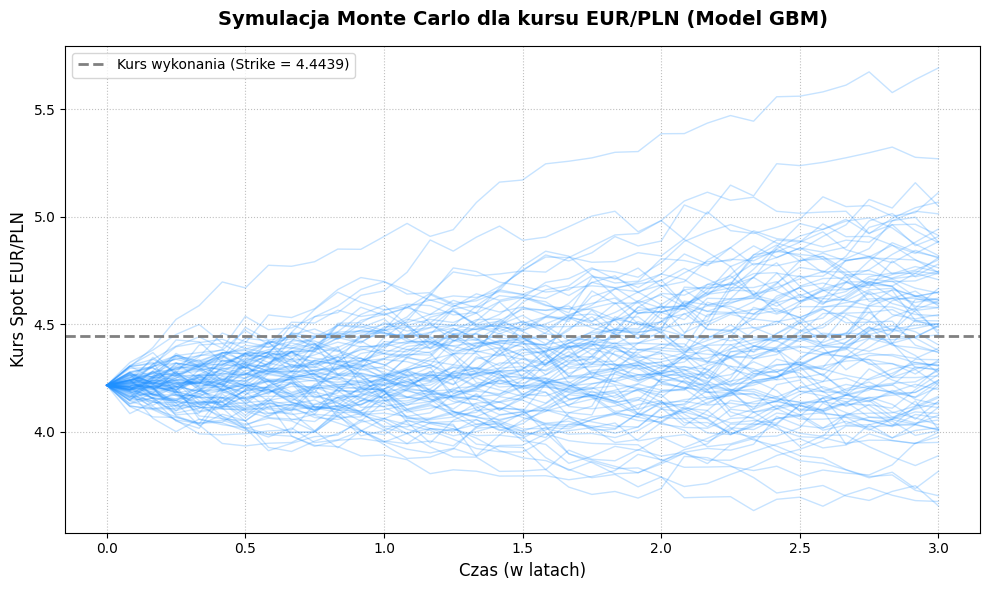

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(time_grid, S_paths[:, :100], color='dodgerblue', alpha=0.25, linewidth=1)
plt.axhline(y=strike, color='gray', linestyle='--', linewidth=2, label=f'Kurs wykonania (Strike = {strike})')
plt.title('Symulacja Monte Carlo dla kursu EUR/PLN (Model GBM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Czas (w latach)', fontsize=12)
plt.ylabel('Kurs Spot EUR/PLN', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.8)
plt.tight_layout()
plt.savefig("GBM_Simulated_Paths.png", dpi=300)
plt.show()

## 6. Walidacja modelu (sanity checks)

Poprawność implementacji weryfikujemy dwoma niezależnymi testami:

1. **Fair value w $t=0$** — średnia symulowanych MtM powinna odtwarzać wzór analityczny:
$$V_0 = N\big(S_0\, e^{-r_{EUR}T} - K\, e^{-r_{PLN}T}\big)$$
2. **Payoff w $t=T$** — przy $DF=1$ wartość kontraktu na danej ścieżce musi równać się $N\,(S(T)-K)$.

Zgodność obu par liczb potwierdza spójność dyskontowania, driftu i konstrukcji payoffu.

In [8]:
print(" SANITY CHECKS")
V0_analytical = notional_eur * (S0 * np.exp(-r_eur * T_years) - strike * np.exp(-r_pln * T_years))
print(f"Fair Value w t=0 (analitycznie): {V0_analytical:,.2f} PLN")
print(f"Średnia symulacji MtM w t=0: {np.mean(MtM_paths[0]):,.2f} PLN")

 SANITY CHECKS
Fair Value w t=0 (analitycznie): 3.50 PLN
Średnia symulacji MtM w t=0: 3.50 PLN


## 7. Profil ryzyka kredytowego — EE i PFE(95%)

Wykres profilu Expected Exposure oraz Potential Future Exposure na poziomie 95. percentyla, z naniesionymi wartościami w wybranych punktach czasowych. Numerycznie wyznaczamy również moment osiągnięcia maksimum EE.

In [ ]:
peak_idx = np.argmax(EE_profile)
print(f"Numeryczne maksimum EE: t = {time_grid[peak_idx]:.1f} lat, wartość = {EE_profile[peak_idx]:,.0f} PLN")

plt.figure(figsize=(10, 6))
plt.plot(time_grid, EE_profile, color='#004488', linewidth=2.5, marker='o', markersize=4, label='Expected Exposure (EE)')
plt.plot(time_grid, PFE_95, color='#d62728', linewidth=2, linestyle='--', label='PFE (95th Percentile)')
plt.fill_between(time_grid, EE_profile, color='#004488', alpha=0.1)

target_times = [0.5, 1, 1.5, 2, 2.5, 3]
for t in target_times:
    idx = np.abs(time_grid - t).argmin()

    plt.text(time_grid[idx], EE_profile[idx] + 5000,
             f'{EE_profile[idx]:,.0f}',
             fontsize=9, fontweight='bold', color='#004488', ha='center')

    plt.text(time_grid[idx], PFE_95[idx] + 5000,
             f'{PFE_95[idx]:,.0f}',
             fontsize=9, fontweight='bold', color='#d62728', ha='center')

plt.title('Profil Ryzyka Kredytowego (EE & PFE 95%) - FX Forward EUR/PLN', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Czas (w latach)', fontsize=12)
plt.ylabel('Ekspozycja w PLN', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.8)
plt.ylim(0, max(PFE_95) * 1.15)
plt.tight_layout()
plt.savefig("EE_PFE_FX_Forward_Plot.png", dpi=300)
plt.show()

## 8. Cechy charakterystyczne profilu EE — FX Forward

FX Forward to instrument z **pojedynczą płatnością terminową** (bullet payment) w $T$, co w pełni determinuje kształt profilu:

- **Monotoniczny wzrost EE** — niepewność kursu $S(T)$ rośnie z czasem ($\sigma\sqrt{t}$ w GBM), więc oczekiwana dodatnia ekspozycja systematycznie rośnie.
- **Brak amortyzacji** — w odróżnieniu od IRS nie ma pośrednich płatności redukujących ekspozycję; cała wymiana następuje raz, w $T$.
- **Peak EE przy $T=3$** — maksymalna ekspozycja tuż przed rozliczeniem (najwyższa skumulowana zmienność i najmniejsze dyskonto jednocześnie).
- **Brak skoków (sawtooth)** — gładki, jednostajnie rosnący profil; charakterystyczne "zęby piły" pojawiają się dopiero przy instrumentach wielopłatnościowych (IRS, punkt IV).
- **Dodatni drift forwardu** — ponieważ $r_{PLN} > r_{EUR}$, forward dryfuje w górę, co dodatkowo zwiększa moneyness pozycji long EUR i podbija EE.

## 9. Podsumowanie wykonania punktu III

| Wymaganie | Status |
|---|---|
| Kalibracja do danych rynkowych | ✓ $\sigma$ z log-zwrotów Stooq (okno 2024–2025) |
| Symulacja: 3y horyzont, krok 1M | ✓ 36 kroków, dt = 1/12 |
| Min. 10 000 symulacji | ✓ n_sim = 10 000, seed = 42 |
| Wycena MtM | ✓ Forward EUR/PLN z dyskontowaniem dwuwalutowym |
| Profile EE i PFE | ✓ EE = E[max(MtM,0)], PFE = Q₉₅ |
| Walidacja (sanity checks) | ✓ Fair value t=0 + payoff t=T vs. analityka |
| Identyfikacja cech profilu EE | ✓ Monotoniczny wzrost, peak przy T (bullet) |

**Ścieżki `S_paths`, profil `EE_profile` oraz `PFE_95` są dostępne jako zmienne — gotowe wejście do punktu V (CVA portfelowe, netting z IRS).**